# Python Packages in use

In [4]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt
import importlib
import os
import math
from scipy.optimize import curve_fit
import statistics as stat

# Processing the HURDAT2 dataset

In [15]:
file_path = "data/hurdat2-1851-2024-040425.csv"

records = []
storm_id, storm_name = None, None

with open(file_path, "r") as f:
    for line in f:
        parts = [p.strip() for p in line.split(",")]
        if len(parts) == 4:
            storm_id, storm_name, count, nan = parts
            continue
        
        if len(parts) > 4:
            date, time, record_id, status, lat, lon, maxwind, minpressure, thirtyne, thirtyse, thirtysw, thirtynw, fivene, fivese, fivesw, fivenw, sixne, sixse, sixsw, sixnw, radmaxwind = parts
            records.append([
                storm_id, storm_name, date, time, record_id, status,
                lat, lon, maxwind, minpressure, thirtyne, thirtyse, thirtysw,
                thirtynw, fivene, fivese, fivesw, fivenw, sixne, sixse, sixsw,
                sixnw, radmaxwind
            ])

# Define column names
cols = ["SID", "Name", "Date", "Time", "RecordID", "Status", "Latitude", "Longitude",
        "MaxWind(kn)", "MinPressure", "34NE", "34SE", "34SW", "34NW", "50NE",
        "50SE", "50SW", "50NW", "64NE", "64SE", "64SW", "64NW", "RadiusOfMaxWind"]

df = pd.DataFrame(records, columns=cols)

df = df.replace(["", " ", "-999"], pd.NA)

quad_cols = [
    '34NE','34SE','34SW','34NW',
    '50NE','50SE','50SW','50NW',
    '64NE','64SE','64SW','64NW'
]
df[quad_cols] = df[quad_cols].apply(pd.to_numeric, errors = 'coerce')
df["Date"] = pd.to_datetime(df["Date"], format="%Y%m%d").dt.date
df["Time"] = pd.to_datetime(df["Time"].str.zfill(4), format="%H%M").dt.time

In [19]:
beryl_df = df[(df["Name"]=="BERYL") & (df["Status"]=="HU") & (pd.notna(df["RadiusOfMaxWind"]))].reset_index()

# Final obtained data on the Hurricane in peak intensity

In [23]:
row = beryl_df.iloc[11]
row

index                   54777
SID                  AL022024
Name                    BERYL
Date               2024-07-02
Time                 09:45:00
RecordID                    I
Status                     HU
Latitude                14.8N
Longitude               67.2W
MaxWind(kn)               145
MinPressure               932
34NE                    150.0
34SE                    100.0
34SW                     60.0
34NW                    100.0
50NE                     60.0
50SE                     50.0
50SW                     40.0
50NW                     50.0
64NE                     35.0
64SE                     30.0
64SW                     20.0
64NW                     30.0
RadiusOfMaxWind            10
Name: 11, dtype: object

# Pressure data from ERA5 notebook

In [26]:
PN = pd.read_csv("data/beryl_pressure_average.csv")
PN = PN['SP']*100

In [30]:
r_data = np.arange(1, len(PN)+1) * 1000
p_data = PN.values
r_data, p_data = r_data[~np.isnan(p_data)], p_data[~np.isnan(p_data)]

# Unit conversions

In [33]:
# Unit Conversions
KNOTS_TO_M_S = 0.514444
NMI_TO_M = 1852.0
NMI_TO_KM = 1.852
HPA_TO_PA = 100.0
BL_REDUCTION_FACTOR = 0.8 

rad34_v = stat.median([float(row['34NE']), float(row['34SE']), float(row['34NW']), float(row['34SW'])])
rad34_v_m = rad34_v * NMI_TO_M
rad34_v_ms = 34.0 * KNOTS_TO_M_S

rad50_v = stat.median([float(row['50NE']), float(row['50SE']), float(row['50NW']), float(row['50SW'])])
rad50_v_m = rad50_v * NMI_TO_M
rad50_v_ms = 50.0 * KNOTS_TO_M_S

rad64_v = stat.median([float(row['64NE']), float(row['64SE']), float(row['64NW']), float(row['64SW'])])
rad64_v_m = rad64_v * NMI_TO_M
rad64_v_ms = 64.0 * KNOTS_TO_M_S

# H80 wind profile model

In [41]:
def holland80(row, r_max=500):
    """
    ym  : maximum wind (m/s)
    rym : radius of max wind (km)
    pcs : central pressure (hPa)
    pns : ambient pressure (hPa)
    """
    ym = float(row['MaxWind(kn)']) * KNOTS_TO_M_S  # Vmax: knots to m/s
    ym = ym * 1.25 # H80 model uses gradient wind speed instead of surface speed
    pcs = float(row['MinPressure']) * HPA_TO_PA       # Pc: hPa to Pa
    rym = float(row['RadiusOfMaxWind']) * NMI_TO_M  # Rmax: nmi to m
    pns = 101335
    # Approximate air density
    rho = 1.15
    # Pressure drop
    dp = pns - pcs
    # b parameter
    b = (ym**2 * rho * np.e) / (dp)
    print(b)
    # Radius array - 1 km spacing
    r_km = np.arange(1, r_max + 1)
    r_m  = r_km * 1000
    # Wind profile
    for i in range(len(r_m)):
        if r_m[i] < rym:
            x = 1
        else:
            x = 0.5
        term = (rym / r_m)**b
        wind = ym * (term * np.exp(1 - term))**x
    wind = wind/1.25
    return r_km.tolist(), wind.tolist()

In [45]:
H80_r_km, H80_wind_ms = holland80(row)
h80_df = pd.DataFrame({
    'Distance_km': H80_r_km,
    'Wind_ms': H80_wind_ms
})

3.340927168591843


# H10 wind profile model

In [48]:
def x_anchor(ym, rym, rad_v_m, rad_v_ms, b):
    ratio = rym / rad_v_m
    denominator = (b * np.log(ratio)) + 1.0 - (ratio)**b
    return np.log(rad_v_ms / ym) / denominator

In [50]:
def interp_x(r, r1, x1, r2, x2):
    return x1 + (x2 - x1) * ((r - r1) / (r2 - r1))

In [52]:
def holland10(row, r_max = 500):
    """
    Simple Holland (2010) wind profile for one input.
    
    ym  : maximum wind (m/s)
    rym : radius of max wind (km)
    pcs : central pressure (hPa)
    pns : ambient pressure (hPa)
    """
    ym = float(row['MaxWind(kn)']) * KNOTS_TO_M_S  # Vmax: knots to m/s
    pcs = float(row['MinPressure']) * HPA_TO_PA       # Pc: hPa to Pa
    rym = float(row['RadiusOfMaxWind']) * NMI_TO_M  # Rmax: nmi to m
    pns = 101335

    # Approximate air density with use of surface pressure approximation
    rho = 1.15
    
    # Pressure drop
    dp = pns - pcs

    # Holland b parameter
    b = (ym**2 * rho * np.e) / (dp)
    print(b)

    # Radius array (1 km spacing)
    r_km = np.arange(1, r_max + 1)
    r_m  = r_km * 1000
    wind = np.zeros_like(r_m, dtype=float)

    x64 = x_anchor(ym, rym, rad64_v_m, rad64_v_ms, b)
    x50 = x_anchor(ym, rym, rad50_v_m, rad50_v_ms, b)
    x34 = x_anchor(ym, rym, rad34_v_m, rad34_v_ms, b)
    
    # Wind profile
    i = 0
    for i in range(len(r_m)):
        if r_m[i] <= rym:
            x = 0.5
        elif r_m[i] <= rad64_v_m:
            x = interp_x(r_m[i], rym, 0.5, rad64_v_m, x64)
        elif r_m[i] <= rad50_v_m:
            x = interp_x(r_m[i], rad64_v_m, x64, rad50_v_m, x50)
        elif r_m[i] <= rad34_v_m:
            x = interp_x(r_m[i], rad50_v_m, x50, rad34_v_m, x34)
        else:
            x = x34
        term = (rym / r_m[i])**b
        wind[i] = ym * (term * np.exp(1 - term))**x

    return r_km.tolist(), wind.tolist()

# Enchanced H10 wind profile model with Pressure Fitting

In [55]:
def holland10_dynamic_pressure(r_data, p_data, row, r_max = 500, quad = None):
    """
    Simple H10 wind profile for one input.
    
    ym  : maximum wind (m/s)
    rym : radius of max wind (km)
    pcs : central pressure (hPa)
    pns : ambient pressure (hPa)
    """
    ym = float(row['MaxWind(kn)']) * KNOTS_TO_M_S  # Vmax: knots to m/s
    pcs = float(row['MinPressure']) * HPA_TO_PA       # Pc: hPa to Pa
    rym = float(row['RadiusOfMaxWind']) * NMI_TO_M  # Rmax: nmi to m
    pns = 101335

    if quad != None:
        rad64_v_m = row[f'64{quad}']*NMI_TO_M
        rad50_v_m = row[f'50{quad}']*NMI_TO_M
        rad34_v_m = row[f'34{quad}']*NMI_TO_M
    else:
        rad64_v_m = rad64_v * NMI_TO_M
        rad50_v_m = rad50_v * NMI_TO_M
        rad34_v_m = rad34_v * NMI_TO_M

    # Approximate air density at the gradient level constant 1.15
    rho = 1.15
    
    # Pressure drop
    dp = pns - pcs

    # Radius array (1 km spacing)
    r_km = np.arange(1, r_max + 1)
    r_m  = r_km * 1000
    wind = np.zeros_like(r_m, dtype=float)

    # Holland b parameter
    b_initial = (ym**2 * rho * np.e) / (dp)
    print(b_initial)

    def holland_pressure_b(r, b):
        p = pcs + (pns - pcs) * np.exp(-(rym / r)**b)
        return p

    b_fit, _ = curve_fit(
        holland_pressure_b,
        r_data,
        p_data,
        p0=[b_initial],
        bounds=(0.5,3.0)
    )
    
    b = b_fit[0]
    print(b)
    
    x64 = x_anchor(ym, rym, rad64_v_m, rad64_v_ms, b)
    x50 = x_anchor(ym, rym, rad50_v_m, rad50_v_ms, b)
    x34 = x_anchor(ym, rym, rad34_v_m, rad34_v_ms, b)

    # Wind profile
    i = 0
    for i in range(len(r_m)):
        if r_m[i] <= rym:
            x = 0.5
        elif r_m[i] <= rad64_v_m:
            x = interp_x(r_m[i], rym, 0.5, rad64_v_m, x64)
        elif r_m[i] <= rad50_v_m:
            x = interp_x(r_m[i], rad64_v_m, x64, rad50_v_m, x50)
        elif r_m[i] <= rad34_v_m:
            x = interp_x(r_m[i], rad50_v_m, x50, rad34_v_m, x34)
        else:
            x = x34
        term = (rym / r_m[i])**b
        wind[i] = ym * (term * np.exp(1 - term))**x

    return r_km.tolist(), wind.tolist()

In [57]:
H10_r_km, H10_wind_ms = holland10(row)
h10_df = pd.DataFrame({
    'Distance_km': H10_r_km,
    'Wind_ms': H10_wind_ms
})

2.13819338789878


In [59]:
H10_r_km_DP, H10_wind_ms_DP = holland10_dynamic_pressure(r_data, p_data, row)
h10_DP_df = pd.DataFrame({
    'Distance_km': H10_r_km_DP,
    'Wind_ms': H10_wind_ms_DP
})

2.13819338789878
1.1859098300854873


# H80 & H10 Plot

In [65]:
def plot_1d_profiles(r_1980_km, v_1980_s_m_s, r_2010_km, v_2010_s_m_s, hurricane_name, v_max_kn):
    RMW = float(row['RadiusOfMaxWind']) * NMI_TO_M / 1000
    plt.figure(figsize=(10, 6))
    
    plt.plot(r_1980_km, v_1980_s_m_s, label='H80 Surface Wind', linewidth=2, color='darkblue')
    
    plt.plot(r_2010_km, v_2010_s_m_s, label='H10 Surface Wind', linewidth=2, color='red')
    
    v_max_m_s = v_max_kn * KNOTS_TO_M_S
    plt.axhline(v_max_m_s, color='gray', linestyle=':', label=f'Max Wind Speed ({v_max_m_s:.1f} m/s)')
    
    plt.axvline(RMW, color='black', linestyle=':', label=f'Radius of Max Wind ({RMW} km)')
    plt.plot(rad34_v_m/1000, 34*KNOTS_TO_M_S, 'k^', label=f'34 kn ({34*KNOTS_TO_M_S:.1f} m/s) wind Radii')
    plt.plot(rad50_v_m/1000, 50*KNOTS_TO_M_S, 'ks', label=f'50 kn ({50*KNOTS_TO_M_S:.1f} m/s) wind Radii')
    plt.plot(rad64_v_m/1000, 64*KNOTS_TO_M_S, 'ko', label=f'64 kn ({64*KNOTS_TO_M_S:.1f} m/s) wind Radii')
    
    plt.title(f'Comparison of Surface Wind Profiles H80 & H10 - {hurricane_name}')
    plt.xlabel('Radius from Center (km)')
    plt.ylabel('Surface Wind Speed (m/s)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.minorticks_on()
    plt.tight_layout()
    plt.savefig(f'holland_plots/1D_H80_H10_comp_{hurricane_name}')
    plt.show()

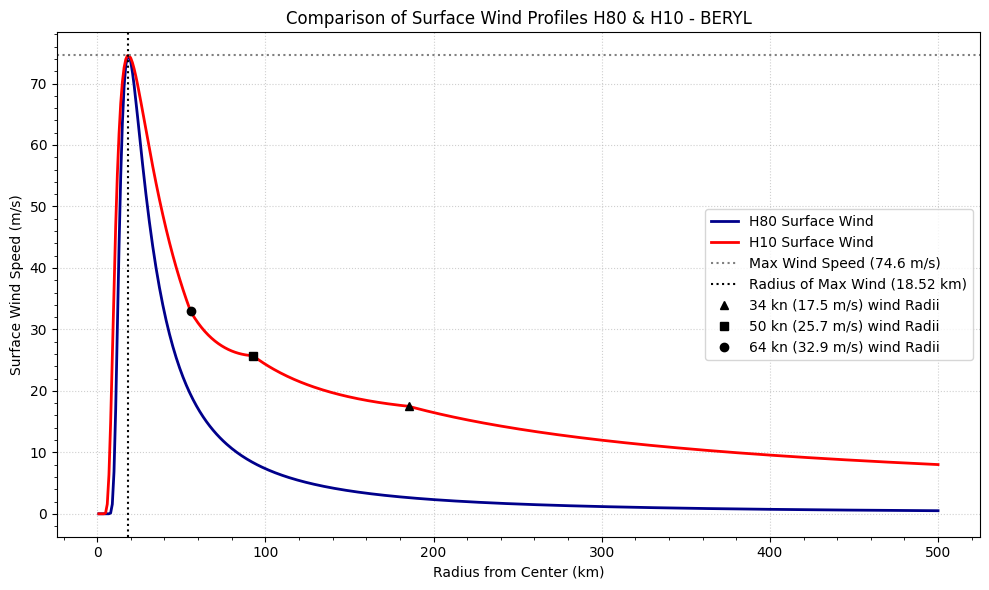

In [67]:
plot_1d_profiles(H80_r_km, H80_wind_ms, H10_r_km, H10_wind_ms, row['Name'], float(row['MaxWind(kn)']))

# H10 orginal & H10 enchanced Plot

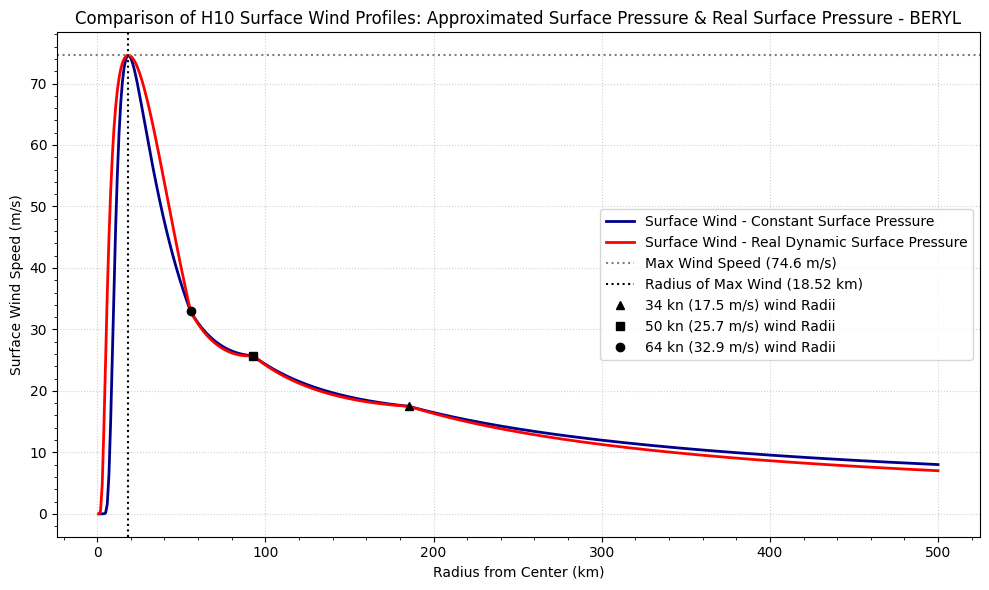

In [70]:
v_max_kn = float(row['MaxWind(kn)'])
hurricane_name  = row['Name']
RMW = float(row['RadiusOfMaxWind']) * NMI_TO_M / 1000
plt.figure(figsize=(10, 6))

# Plot Holland 2010 Surface Wind with constant env pressure
plt.plot(h10_df['Distance_km'], h10_df['Wind_ms'], label='Surface Wind - Constant Surface Pressure', linewidth=2, color='darkblue')

# Plot Holland 2010 Surface Wind with dynamic real-time pressure
plt.plot(h10_DP_df['Distance_km'], h10_DP_df['Wind_ms'], label='Surface Wind - Real Dynamic Surface Pressure', linewidth=2, color='red')

# Vmax line (Input Surface Wind Maximum)
v_max_m_s = v_max_kn * KNOTS_TO_M_S
plt.axhline(v_max_m_s, color='gray', linestyle=':', label=f'Max Wind Speed ({v_max_m_s:.1f} m/s)')

plt.axvline(RMW, color='black', linestyle=':', label=f'Radius of Max Wind ({RMW} km)')
plt.plot(rad34_v_m/1000, 34*KNOTS_TO_M_S, 'k^', label=f'34 kn ({34*KNOTS_TO_M_S:.1f} m/s) wind Radii')
plt.plot(rad50_v_m/1000, 50*KNOTS_TO_M_S, 'ks', label=f'50 kn ({50*KNOTS_TO_M_S:.1f} m/s) wind Radii')
plt.plot(rad64_v_m/1000, 64*KNOTS_TO_M_S, 'ko', label=f'64 kn ({64*KNOTS_TO_M_S:.1f} m/s) wind Radii')

plt.title(f'Comparison of H10 Surface Wind Profiles: Approximated Surface Pressure & Real Surface Pressure - {hurricane_name}')
plt.xlabel('Radius from Center (km)')
plt.ylabel('Surface Wind Speed (m/s)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.minorticks_on()
plt.tight_layout()
plt.savefig(f'holland_plots/1D_H10_pressure_comp_{hurricane_name}')
plt.show()

# Quantatitive analysis

In [74]:
def compare_wind_by_intervals(df1, df2, rmw):
    A = df1['Wind_ms']
    B = df2['Wind_ms']
    rmw = float(rmw)

    # Assume index = radius (km)
    radius = df1['Distance_km']

    # Define bins
    bins = [
        (0, rmw, f"0–{rmw} km"),
        (rmw, rmw+50, f"{rmw}–{rmw+50} km"),
        (rmw+50, rmw+100, f"{rmw+50}–{rmw+100} km"),
        (rmw+100, rmw+200, f"{rmw+100}–{rmw+200} km"),
        (rmw+200, rmw+300, f"{rmw+200}–{rmw+300} km"),
        (rmw+300, np.inf, f"{rmw+300}+ km")
    ]

    rows = []

    for lower, upper, label in bins:
        mask = (radius >= lower) & (radius < upper)

        if mask.sum() == 0:
            continue

        A_bin = A[mask]
        B_bin = B[mask]
        
        diff = A[mask] - B[mask]
        abs_diff = np.abs(diff)

        rmse = np.sqrt(np.mean(diff**2))
        mean_diff = diff.mean()
        max_dev = abs_diff.max()

        mean_ref = (A_bin.mean() + B_bin.mean()) / 2
        rmse_pct = (rmse / mean_ref) * 100 if mean_ref != 0 else np.nan

        rows.append({
            "Interval": label,
            "A Mean": A_bin.mean(),
            "B Mean": B_bin.mean(),
            "Mean difference": diff.mean(),
            "RMSE": rmse,
            "RMSE (%)": rmse_pct,
            "Max deviation": abs_diff.max(),
            "Points": mask.sum()
        })

    return pd.DataFrame(rows).set_index("Interval")

In [76]:
results = compare_wind_by_intervals(h10_df, h80_df, row['RadiusOfMaxWind'])

In [78]:
results = compare_wind_by_intervals(h10_df, h10_DP_df, row['RadiusOfMaxWind'])

# Pressure fields data by quadrants from ERA5 notebook

In [83]:
PN_quad = pd.read_csv("data/Beryl_pressure_average_quadrants.csv")

In [85]:
nw_df = PN_quad[['Distance', 'NW']].dropna()
ne_df = PN_quad[['Distance', 'NE']].dropna()
sw_df = PN_quad[['Distance', 'SW']].dropna()
se_df = PN_quad[['Distance', 'SE']].dropna()

r_data_NW = nw_df['Distance'].to_numpy(dtype=float) * 1000
p_data_NW = nw_df['NW'].to_numpy(dtype=float)

r_data_NE = ne_df['Distance'].to_numpy(dtype=float) * 1000
p_data_NE = ne_df['NE'].to_numpy(dtype=float)

r_data_SW = sw_df['Distance'].to_numpy(dtype=float) * 1000
p_data_SW = sw_df['SW'].to_numpy(dtype=float)

r_data_SE = se_df['Distance'].to_numpy(dtype=float) * 1000
p_data_SE = se_df['SE'].to_numpy(dtype=float)

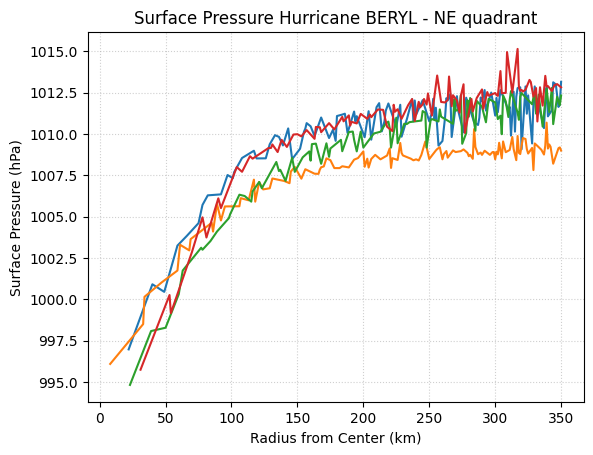

In [89]:
x = np.arange(1, 351)

quadrants = ['SE', 'SW', 'NW', 'NE']

for q in quadrants:
    plt.plot(x, PN_quad[q].head(350)/100)
    plt.title(f"Surface Pressure Hurricane {row['Name']} - {q} quadrant")
    plt.xlabel('Radius from Center (km)')
    plt.ylabel('Surface Pressure (hPa)')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.savefig(f"q_pressure/Surface Pressure Hurricane {row['Name']} - {q} quadrant")
    #plt.show()

# Modelling H10 enchanced by quandrants

In [92]:
H10_r_km_NW, H10_wind_ms_NW = holland10_dynamic_pressure(r_data_NW, p_data_NW, row, quad = 'NW')
h10_NW_df = pd.DataFrame({
    'Distance_km': H10_r_km_NW,
    'Wind_ms': H10_wind_ms_NW
})

H10_r_km_NE, H10_wind_ms_NE = holland10_dynamic_pressure(r_data_NE, p_data_NE, row, quad = 'NE')
h10_NE_df = pd.DataFrame({
    'Distance_km': H10_r_km_NE,
    'Wind_ms': H10_wind_ms_NE
})

H10_r_km_SW, H10_wind_ms_SW = holland10_dynamic_pressure(r_data_SW, p_data_SW, row, quad = 'SW')
h10_SW_df = pd.DataFrame({
    'Distance_km': H10_r_km_SW,
    'Wind_ms': H10_wind_ms_SW
})

H10_r_km_SE, H10_wind_ms_SE = holland10_dynamic_pressure(r_data_SE, p_data_SE, row, quad = 'SE')
h10_SE_df = pd.DataFrame({
    'Distance_km': H10_r_km_SE,
    'Wind_ms': H10_wind_ms_SE
})

2.13819338789878
0.8483298930431606
2.13819338789878
1.6049175096576112
2.13819338789878
0.9799886654968889
2.13819338789878
1.9339987520671698


# H10 original & H10 enchanced assymetric quandrants Plot

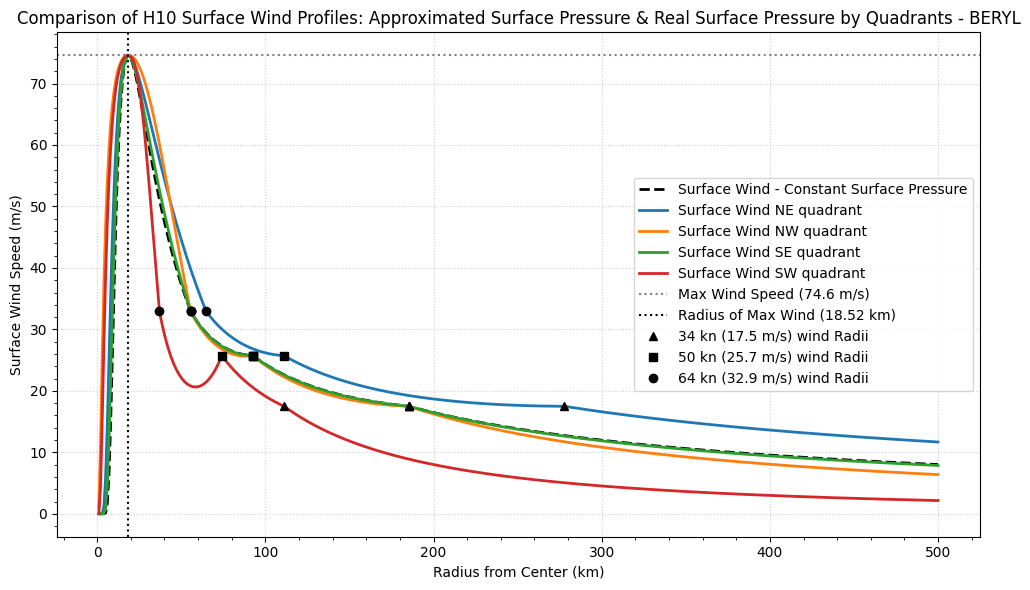

In [98]:
v_max_kn = float(row['MaxWind(kn)'])
hurricane_name  = row['Name']
RMW = float(row['RadiusOfMaxWind']) * NMI_TO_M / 1000
plt.figure(figsize=(10, 6))

# Plot Holland 2010 Surface Wind with constant env pressure
plt.plot(h10_df['Distance_km'], h10_df['Wind_ms'], label='Surface Wind - Constant Surface Pressure', linewidth=2, linestyle='--', color='black')

# Plot Holland 2010 Surface Wind with dynamic real-time pressure
plt.plot(h10_NE_df['Distance_km'], h10_NE_df['Wind_ms'], label='Surface Wind NE quadrant', linewidth=2)
plt.plot(h10_NW_df['Distance_km'], h10_NW_df['Wind_ms'], label='Surface Wind NW quadrant', linewidth=2)
plt.plot(h10_SE_df['Distance_km'], h10_SE_df['Wind_ms'], label='Surface Wind SE quadrant', linewidth=2)
plt.plot(h10_SW_df['Distance_km'], h10_SW_df['Wind_ms'], label='Surface Wind SW quadrant', linewidth=2)

# Vmax line (Input Surface Wind Maximum)
v_max_m_s = v_max_kn * KNOTS_TO_M_S
plt.axhline(v_max_m_s, color='gray', linestyle=':', label=f'Max Wind Speed ({v_max_m_s:.1f} m/s)')

plt.axvline(RMW, color='black', linestyle=':', label=f'Radius of Max Wind ({RMW} km)')

plt.plot(rad34_v_m/1000, 34*KNOTS_TO_M_S, 'k^', label=f'34 kn ({34*KNOTS_TO_M_S:.1f} m/s) wind Radii')
plt.plot(row['34NE']*NMI_TO_KM, 34*KNOTS_TO_M_S, 'k^')
plt.plot(row['34NW']*NMI_TO_KM, 34*KNOTS_TO_M_S, 'k^')
plt.plot(row['34SE']*NMI_TO_KM, 34*KNOTS_TO_M_S, 'k^')
plt.plot(row['34SW']*NMI_TO_KM, 34*KNOTS_TO_M_S, 'k^')

plt.plot(rad50_v_m/1000, 50*KNOTS_TO_M_S, 'ks', label=f'50 kn ({50*KNOTS_TO_M_S:.1f} m/s) wind Radii')
plt.plot(row['50NE']*NMI_TO_KM, 50*KNOTS_TO_M_S, 'ks')
plt.plot(row['50NW']*NMI_TO_KM, 50*KNOTS_TO_M_S, 'ks')
plt.plot(row['50SE']*NMI_TO_KM, 50*KNOTS_TO_M_S, 'ks')
plt.plot(row['50SW']*NMI_TO_KM, 50*KNOTS_TO_M_S, 'ks')

plt.plot(rad64_v_m/1000, 64*KNOTS_TO_M_S, 'ko', label=f'64 kn ({64*KNOTS_TO_M_S:.1f} m/s) wind Radii')
plt.plot(row['64NE']*NMI_TO_KM, 64*KNOTS_TO_M_S, 'ko')
plt.plot(row['64NW']*NMI_TO_KM, 64*KNOTS_TO_M_S, 'ko')
plt.plot(row['64SE']*NMI_TO_KM, 64*KNOTS_TO_M_S, 'ko')
plt.plot(row['64SW']*NMI_TO_KM, 64*KNOTS_TO_M_S, 'ko')

plt.title(f'Comparison of H10 Surface Wind Profiles: Approximated Surface Pressure & Real Surface Pressure by Quadrants - {hurricane_name}')
plt.xlabel('Radius from Center (km)')
plt.ylabel('Surface Wind Speed (m/s)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.minorticks_on()
plt.tight_layout()
plt.savefig(f'holland_plots/1D_H10_pressure_comp_quads_{hurricane_name}')
plt.show()